# European Option Pricing with Black–Scholes

## 1. Setup

In [19]:
import urllib.request, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import log, sqrt, exp, erf


## 2. Download real market data

In [20]:
TICKER="AAPL"
url= f"https://query1.finance.yahoo.com/v8/finance/chart/{TICKER}?range=3y&interval=1d"
req=urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
js = json.loads(urllib.request.urlopen(req, timeout=30).read())

res =js["chart"]["result"][0]
dates= pd.to_datetime(res["timestamp"], unit="s").normalize()
adj= res["indicators"]["adjclose"][0]["adjclose"]   #adjusted close price (accounts for dividends and splits) !!
prices = pd.Series(adj, index=dates, name=TICKER).dropna()  #historical series of adjusted prices              !!

prices.index.name= "date"

prices

,AAPL
date,
2023-09-26,169.665253
2023-09-27,168.155670
2023-09-28,168.412216
2023-09-29,168.925278
2023-10-02,171.431381
...,...
2026-09-21,338.980011
2026-09-22,339.750000
2026-09-23,337.019989


In [21]:
prices.describe()

,AAPL
count,753.000000
mean,232.112375
std,43.626504
min,163.220627
25%,195.723831
50%,226.306870
75%,260.341370
max,341.070007


## 3. Understand the asset

We compute the **log-returns** `r_t = ln(P_t / P_{t-1})`

In [22]:
log_returns= np.log(prices/prices.shift(1)).dropna()
log_returns

,AAPL
date,
2023-09-27,-0.008937
2023-09-28,0.001524
2023-09-29,0.003042
2023-10-02,0.014727
2023-10-03,-0.007800
...,...
2026-09-21,0.008443
2026-09-22,0.002269
2026-09-23,-0.008068


In [23]:
log_returns.describe()

,AAPL
count,752.000000
mean,0.000929
std,0.016795
min,-0.097013
25%,-0.006876
50%,0.001285
75%,0.008991
max,0.142617


In [24]:
TRADING_DAYS = 252  # market convention for daily data

ann_return = log_returns.mean() * TRADING_DAYS
daily_vol  =log_returns.std(ddof=1)
ann_vol    =daily_vol * np.sqrt(TRADING_DAYS)      # historical volatility
running_max = prices.cummax()
max_drawdown = (prices / running_max - 1).min()

summary = pd.Series({
    "Observations":            len(prices),
    "Last price":              prices.iloc[-1],
    "Annualised return":       ann_return,
    "Annualised volatility":   ann_vol,
    "Daily volatility":        daily_vol,
    "Max drawdown":            max_drawdown,
})
summary

,0
Observations,753.000000
Last price,341.070007
Annualised return,0.233992
Annualised volatility,0.266620
Daily volatility,0.016795
Max drawdown,-0.333605


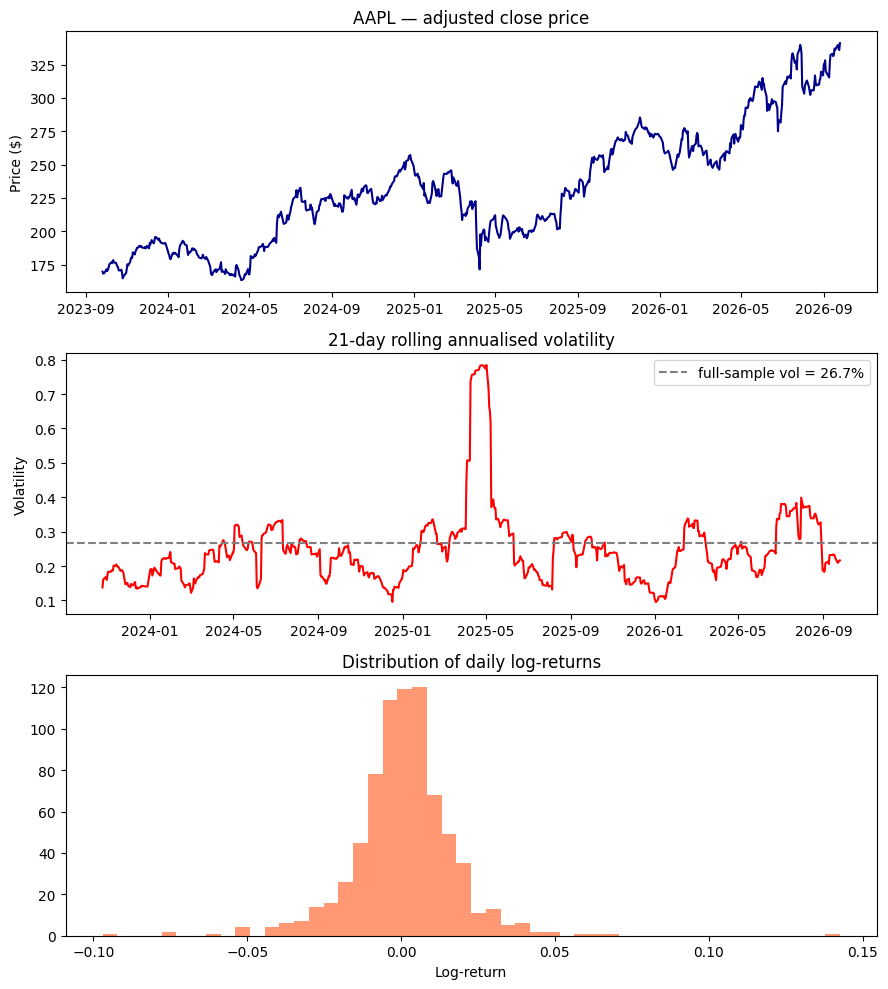

In [25]:
rolling_vol =log_returns.rolling(21).std(ddof=1)* np.sqrt(TRADING_DAYS)

fig,ax = plt.subplots(3, 1, figsize=(9, 10))
ax[0].plot(prices.index, prices.values, color="darkblue")
ax[0].set_title(f"{TICKER} — adjusted close price"); ax[0].set_ylabel("Price ($)")

ax[1].plot(rolling_vol.index, rolling_vol.values, color="red")
ax[1].axhline(ann_vol, ls="--", color="gray", label=f"full-sample vol = {ann_vol:.1%}")
ax[1].set_title("21-day rolling annualised volatility"); ax[1].set_ylabel("Volatility"); ax[1].legend()

ax[2].hist(log_returns.values, bins=50, color="coral", alpha=0.8)
ax[2].set_title("Distribution of daily log-returns"); ax[2].set_xlabel("Log-return")
fig.tight_layout()

## 4. The Black–Scholes–Merton model

- Note: max(S − K, 0) is the option's value at expiration. The Black-Scholes formula is its value today, which adds the time value — the worth of the remaining uncertainty and the chance of future gains. That gap is exactly why options are traded for a premium.


 - For a European option on an underlying with continuous dividend yield `q`:

$$C = S e^{-qT} N(d_1) - K e^{-rT} N(d_2)$$
$$P = K e^{-rT} N(-d_2) - S e^{-qT} N(-d_1)$$
$$d_1 = \frac{\ln(S/K) + (r - q + \tfrac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

 - where `N(·)` is the standard normal CDF.

| Symbol | Meaning |
|--------|---------|
| `S` | spot price of the underlying |
| `K` | strike price |
| `T` | time to maturity (years) |
| `r` | risk-free rate |
| `σ` | annual volatility |
| `q` | continuous dividend yield |

 - *Note: historical volatility is a natural estimate of the `σ` input to Black–Scholes; in practice traders also use the implied volatility backed out from market option prices.*

In [26]:
def _norm_cdf(x):
    return 0.5 * (1 + erf(x / sqrt(2)))

def _norm_pdf(x):
    return exp(-0.5 * x * x) / sqrt(2 * np.pi)

def _d1_d2(S, K, T, r, sigma, q=0.0):
    d1 = (log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * sqrt(T))
    return d1, d1 - sigma * sqrt(T)

def bs_price(S, K, T, r, sigma, q=0.0, option="call"):
    d1, d2 = _d1_d2(S, K, T, r, sigma, q)
    if option == "call":
        return S*exp(-q*T)*_norm_cdf(d1) - K*exp(-r*T)*_norm_cdf(d2)
    return K*exp(-r*T)*_norm_cdf(-d2) - S*exp(-q*T)*_norm_cdf(-d1)

### The Greeks

Sensitivities of the option price to the risk factors. Conventions: **vega** and **rho** per 1% move, **theta** per calendar day.

In [27]:
def bs_greeks(S, K, T, r, sigma, q=0.0, option="call"):
    d1, d2 = _d1_d2(S, K, T, r, sigma, q)
    pdf =_norm_pdf(d1)
    gamma= exp(-q*T) * pdf /(S * sigma * sqrt(T))
    vega  = S * exp(-q*T) * pdf * sqrt(T) / 100
    if option == "call":
        delta= exp(-q*T) * _norm_cdf(d1)
        theta = (-S*exp(-q*T)*pdf*sigma/(2*sqrt(T))- r*K*exp(-r*T)*_norm_cdf(d2)
                 + q*S*exp(-q*T)*_norm_cdf(d1)) / 365
        rho   = K*T*exp(-r*T)*_norm_cdf(d2) / 100
    else:
        delta = exp(-q*T) * (_norm_cdf(d1) - 1)
        theta = (-S*exp(-q*T)*pdf*sigma/(2*sqrt(T)) + r*K*exp(-r*T)*_norm_cdf(-d2)
                 - q*S*exp(-q*T)*_norm_cdf(-d1)) / 365
        rho   = -K*T*exp(-r*T)*_norm_cdf(-d2) / 100
    return {"delta": delta, "gamma": gamma, "vega": vega, "theta": theta, "rho": rho}

## 5. Price an option on the real asset

We price an **at-the-money** option (strike = last price), with 1 year to maturity, using the **historical volatility** estimated above as the model input `σ`.

At the money (ATM) in options trading refers to a situation where the option’s strike price is equal to the current market price of its underlying asset.

In [28]:
S = float(prices.iloc[-1])   # spot = last real price
K = round(S)                 # at-the-money
T = 1.0                      # 1 year
r = 0.04                     # risk-free rate (~ current short rate)
sigma = float(ann_vol)       # historical volatility as sigma

call = bs_price(S, K, T, r, sigma, option="call")
put  = bs_price(S, K, T, r, sigma, option="put")

print(f"Underlying ({TICKER}): S = {S:.2f},  K = {K},  T = {T}yr,  r = {r:.0%},  sigma = {sigma:.1%}\n")
print(f"European CALL price: {call:.2f}")
print(f"European PUT  price: {put:.2f}")


Underlying (AAPL): S = 341.07,  K = 341,  T = 1.0yr,  r = 4%,  sigma = 26.7%

European CALL price: 42.58
European PUT  price: 29.14


# 6. Greeks

- Options traders rely on mathematical gauges, named after Greek letters, to understand how different market conditions affect their options positions.
- **Delta** shows how much an option's price will change relative to a $1 move in the underlying stock, ranging from -1.0 to +1.0.
- **Gamma** measures how quickly delta changes as the underlying stock price moves, helping traders understand the risks in rapid price swings.
- **Theta** calculates how much value an option loses each day as it approaches expiration, with the change accelerating as the expiry date approaches.
- **Vega** indicates how sensitive an option's price is to changes in expected market volatility, with longer-dated options generally being more sensitive.

In [29]:
greeks = pd.DataFrame({
    "call": bs_greeks(S, K, T, r, sigma, option="call"),
    "put":  bs_greeks(S, K, T, r, sigma, option="put"),
})
print("\nGreeks:")
greeks


Greeks:


,call,put
delta,0.611836,-0.388164
gamma,0.004214,0.004214
vega,1.306852,1.306852
theta,-0.065933,-0.030029
rho,1.661001,-1.615291


# 7. Put-call parity
- Put-call parity describes the relationship between the prices of European call options and European put options with the same strike price and expiration date.

- **It ensures that these options are priced fairly relative to each other and the underlying asset.** If their prices move out of balance, investors may take advantage of arbitrage opportunities by trading related securities. Keep reading to learn how the put-call parity equation works, the key components, and how you can use it to evaluate option prices and identify inefficiencies

- If this equation holds, the options market is in equilibrium, with no arbitrage prospects available. However, if the prices of the put and call options diverge from the value predicted by put-call parity, one exists. Traders can exploit this mispricing by simultaneously buying the underpriced option and selling the overpriced option, locking in a risk-free profit.

In [30]:
# Put-call parity check (no-arbitrage):  C - P = S - K e^{-rT}
lhs = call - put
rhs = S - K * exp(-r * T)
print(f"C - P            = {lhs:.4f}")
print(f"S - K e^(-rT)    = {rhs:.4f}")
print(f"parity holds     = {np.isclose(lhs, rhs)}")

C - P            = 13.4408
S - K e^(-rT)    = 13.4408
parity holds     = True
